# 17 — Detection validation: MER catalogue, injection-recovery, multi-band gain, MER fine-tune

Reproducible, plotted validation of the v10 detector. Every test here calls committed code in
`models/detection/validation_utils.py` (frozen detector — no training in this notebook) so the
results are inspectable and re-runnable, not opaque numbers.

**Tests**
1. **MER catalogue match** — completeness/purity vs VIS magnitude against the real Euclid Q1 MER FINAL catalogue.
2. **Injection-recovery** — catalogue-*independent* completeness depth via source-recycling injection.
3. **Multi-band gain** — VIS-only vs all-10-band injection; the gap is the foundation's detection value.
4. **MER fine-tune** — does training the head on MER labels help? Baseline vs fine-tuned on a held-out tile.

**Caveats:** the MER catalogue is Euclid **Q1**; the imaging is likely **DR1** (same sky, different release; tile-IDs differ between releases so we query MER by RA/Dec). Magnitudes are VIS AB = `23.9 - 2.5*log10(flux_detection_total[uJy])`. Bump the `NT_*` tile counts for more statistics.

In [1]:
%matplotlib inline
import sys
from pathlib import Path
import numpy as np, torch, matplotlib.pyplot as plt
REPO = Path.cwd().parent if Path.cwd().name == 'io' else Path.cwd()
for p in (str(REPO/'models'), str(REPO/'models'/'astrometry2')):
    if p not in sys.path: sys.path.insert(0, p)
import os; os.chdir(REPO)  # so the relative data/ paths in validation_utils resolve
from detection.validation_utils import (load_detector, load_mer, eval_mer, completeness_curve,
                                         eval_injection, rec_to_curve)

ENC = 'models/checkpoints/jaisp_v10_warmstart/checkpoint_best.pt'
CN_BASE = 'checkpoints/centernet_v10_uncertain_synth_r2/centernet_best.pt'
CN_FT   = 'checkpoints/centernet_v10_MERfinetune/centernet_best.pt'
MER_FITS = 'data/edf_s_ood/catalogs_compact/mer_FINAL_q1_ECDFS_footprint.fits'
EUCLID, RUBIN = 'data/euclid_tiles_all', 'data/rubin_tiles_all'

# tile -> DR1 MER-tile map (held-out tile 533 reserved for the fine-tune test)
import glob
from astropy.wcs import WCS
tilemap = {}
for et in sorted(glob.glob(f'{EUCLID}/*_euclid.npz')):
    stem = os.path.basename(et).replace('_euclid.npz',''); d = np.load(et, allow_pickle=True)
    tilemap[stem] = str(d['euclid_tile_id'])
HELD = 'TILE101374533'
train_side = sorted(s for s,t in tilemap.items() if t != HELD)
held_side  = sorted(s for s,t in tilemap.items() if t == HELD)
NT_MER, NT_INJ, NT_FT = 20, 10, 12   # tile counts per test (raise for more stats)

mer = load_mer(MER_FITS)
det, device = load_detector(CN_BASE, ENC)
print('baseline detector loaded on', device)
print(f'tiles: train-side {len(train_side)}, held-out {len(held_side)} ({HELD})')

JAISPFoundationV10: 9.2M trainable parameters
  stem_ch=64, hidden_ch=256, fused_scale=0.40"/px
  stream_depths={'rubin': 1, 'euclid': 2}
  rubin_concat=True  (symmetric concat fusion)
  loss_type=charbonnier  charbonnier_eps=0.001  core_l2_weight=0.2  core_info_thr=0.5
  rubin decoder channels: [128]
  euclid decoder channels: [256, 128]
Loaded v10 foundation (fused_scale=0.4, rubin_concat=True, loss=charbonnier, core_l2=0.2) from models/checkpoints/jaisp_v10_warmstart/checkpoint_best.pt


baseline detector loaded on cuda
tiles: train-side 587, held-out 204 (TILE101374533)


## Test 1 — Detection vs the MER FINAL catalogue
Completeness = fraction of clean MER VIS sources (`vis_det & !spurious`) recovered within 0.5″, binned by VIS mag. Purity = fraction of detections matched to the full catalogue (a lower bound). The match-offset histogram is an independent astrometric cross-check.

overall completeness 88.7%   purity 62.0%   median offset 54 mas  (20 tiles)


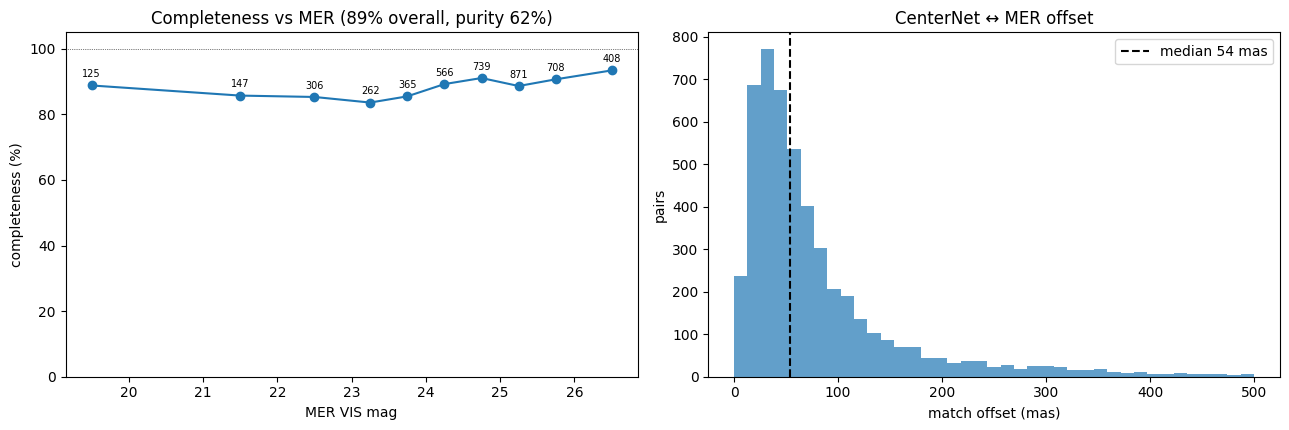

In [2]:
stems = train_side[:NT_MER]
mag, hit, purity, offs = eval_mer(det, stems, mer, EUCLID, RUBIN, device)
cen, comp, n = completeness_curve(mag, hit, np.array([18,21,22,23,23.5,24,24.5,25,25.5,26,27]))
print(f'overall completeness {100*hit.mean():.1f}%   purity {100*purity:.1f}%   median offset {np.median(offs):.0f} mas  ({len(stems)} tiles)')

fig, ax = plt.subplots(1, 2, figsize=(13, 4.4))
ax[0].plot(cen, comp, 'o-', color='C0'); ax[0].axhline(100, color='k', lw=.5, ls=':'); ax[0].set_ylim(0,105)
for x,y,nn in zip(cen,comp,n): ax[0].annotate(f'{nn}',(x,y),textcoords='offset points',xytext=(0,6),fontsize=7,ha='center')
ax[0].set_xlabel('MER VIS mag'); ax[0].set_ylabel('completeness (%)')
ax[0].set_title(f'Completeness vs MER ({100*hit.mean():.0f}% overall, purity {100*purity:.0f}%)')
ax[1].hist(offs, bins=np.linspace(0,500,40), color='C0', alpha=.7); ax[1].axvline(np.median(offs),color='k',ls='--',label=f'median {np.median(offs):.0f} mas')
ax[1].set_xlabel('match offset (mas)'); ax[1].set_ylabel('pairs'); ax[1].set_title('CenterNet ↔ MER offset'); ax[1].legend()
plt.tight_layout(); plt.show()

## Test 2 — Injection-recovery: the true detection depth
Catalogue-independent. Real isolated **compact** MER sources are scaled to a target magnitude and injected (all 10 bands, real PSF+SED) at empty positions; the frozen detector is re-run and recovery measured. Unlike MER-matching, this is unbiased by MER's own incompleteness, so the roll-off is the real depth.

injection completeness: {22.5: 97.8, 23.5: 96.7, 24.0: 95.6, 24.5: 93.3, 25.0: 80.0, 25.5: 54.4, 26.0: 37.8, 26.5: 32.2}


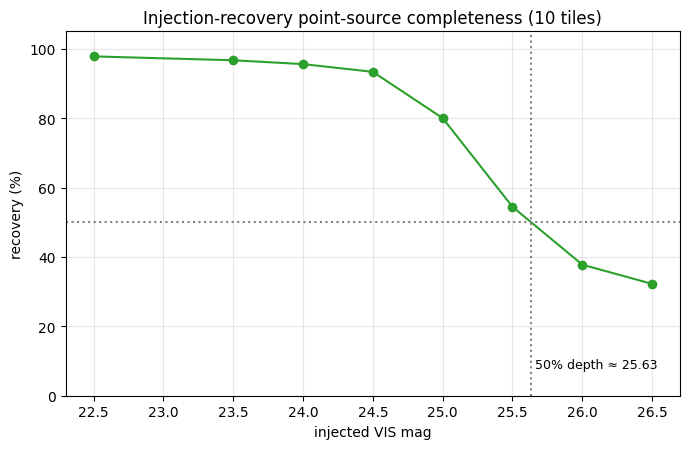

In [3]:
TARGET_MAGS = (22.5,23.5,24.0,24.5,25.0,25.5,26.0,26.5)
rec = eval_injection(det, train_side[:NT_INJ], mer, EUCLID, RUBIN, device,
                     modes=('all',), target_mags=TARGET_MAGS, n_per_mag=10)
mg, cv = rec_to_curve(rec['all'], TARGET_MAGS)
# 50% depth by linear interpolation
order = np.argsort(mg); d50 = np.interp(50, cv[order][::-1], mg[order][::-1]) if cv.min()<50<cv.max() else np.nan
print('injection completeness:', dict(zip(mg, np.round(cv,1))))
plt.figure(figsize=(7,4.6))
plt.plot(mg, cv, 'o-', color='C2'); plt.axhline(50, color='grey', ls=':')
if np.isfinite(d50): plt.axvline(d50, color='grey', ls=':'); plt.text(d50+0.03, 8, f'50% depth ≈ {d50:.2f}', fontsize=9)
plt.ylim(0,105); plt.xlabel('injected VIS mag'); plt.ylabel('recovery (%)')
plt.title(f'Injection-recovery point-source completeness ({NT_INJ} tiles)'); plt.grid(alpha=.3); plt.tight_layout(); plt.show()

## Test 3 — Detection gain by band subset (which bands does the detector actually use?)

Same source-recycling injection, but place the donor's flux only in a chosen band subset (matched donors/positions/mags): **VIS-only**, **Rubin optical-only**, **NISP-only**, and **all 10 bands**. Differences isolate where the detector's sensitivity comes from.

The **NISP-only** curve is a deliberate **high-z dropout proxy**: a Lyman-break source at high redshift can vanish from the optical (Rubin + VIS) yet remain present in the NIR (Y/J/H). If the fused detector recovers NISP-only injections, it can find such sources that an optical/VIS-driven catalogue (like MER's VIS detection) would miss — a concrete multi-band science win. Note the x-axis is the donor's VIS-equivalent magnitude scaling; a real dropout would be intrinsically faint/absent in the dropped bands, so NISP-only recovery here is the *upper bound* on the detector's NIR-only reach at that flux level.

all - vis  : {22.5: 13.3, 23.5: 13.3, 24.0: 4.4, 24.5: 5.6, 25.0: 13.3, 25.5: 16.7, 26.0: 11.1, 26.5: 11.1}
nisp-only  : {22.5: 96.7, 23.5: 80.0, 24.0: 66.7, 24.5: 56.7, 25.0: 32.2, 25.5: 20.0, 26.0: 8.9, 26.5: 6.7}   <- high-z optical-dropout proxy


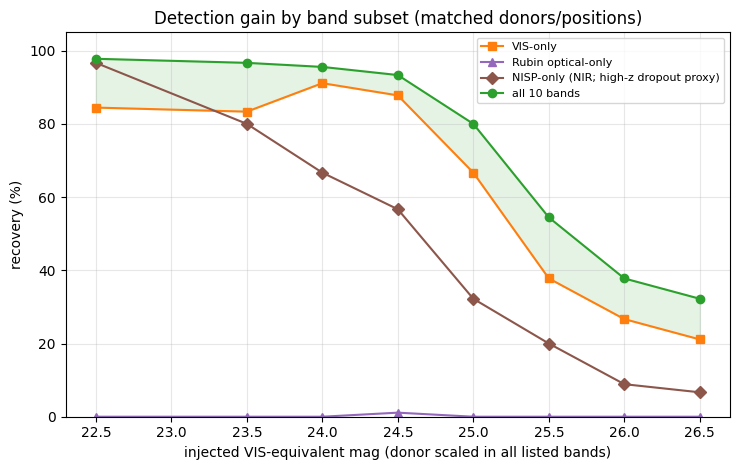

In [4]:
rec2 = eval_injection(det, train_side[:NT_INJ], mer, EUCLID, RUBIN, device,
                      modes=('vis','nisp','rubin','all'), target_mags=TARGET_MAGS, n_per_mag=10)
mg, cvis  = rec_to_curve(rec2['vis'],   TARGET_MAGS)
_,  cnisp = rec_to_curve(rec2['nisp'],  TARGET_MAGS)
_,  crub  = rec_to_curve(rec2['rubin'], TARGET_MAGS)
_,  call  = rec_to_curve(rec2['all'],   TARGET_MAGS)
print('all - vis  :', dict(zip(mg, np.round(call-cvis,1))))
print('nisp-only  :', dict(zip(mg, np.round(cnisp,1))), '  <- high-z optical-dropout proxy')
plt.figure(figsize=(7.5,4.8))
plt.plot(mg, cvis,  's-', color='C1', label='VIS-only')
plt.plot(mg, crub,  '^-', color='C4', label='Rubin optical-only')
plt.plot(mg, cnisp, 'D-', color='C5', label='NISP-only (NIR; high-z dropout proxy)')
plt.plot(mg, call,  'o-', color='C2', label='all 10 bands')
plt.fill_between(mg, cvis, call, color='C2', alpha=.12)
plt.ylim(0,105); plt.xlabel('injected VIS-equivalent mag (donor scaled in all listed bands)')
plt.ylabel('recovery (%)'); plt.title('Detection gain by band subset (matched donors/positions)')
plt.legend(fontsize=8); plt.grid(alpha=.3); plt.tight_layout(); plt.show()

## Test 4 — Training the detector on MER labels (held-out)
Does supervising the head with the real catalogue help? Baseline (classical+synthetic labels) vs the MER-fine-tuned head (`models/detection/finetune_centernet_mer.py`), both evaluated on the **held-out** DR1 tile 533 (never trained). Compared at fixed `conf=0.30` — so this reads the operating point, not the full precision/recall frontier.

JAISPFoundationV10: 9.2M trainable parameters
  stem_ch=64, hidden_ch=256, fused_scale=0.40"/px
  stream_depths={'rubin': 1, 'euclid': 2}
  rubin_concat=True  (symmetric concat fusion)
  loss_type=charbonnier  charbonnier_eps=0.001  core_l2_weight=0.2  core_info_thr=0.5
  rubin decoder channels: [128]
  euclid decoder channels: [256, 128]
Loaded v10 foundation (fused_scale=0.4, rubin_concat=True, loss=charbonnier, core_l2=0.2) from models/checkpoints/jaisp_v10_warmstart/checkpoint_best.pt


baseline         MER completeness 96.1%  purity 61.3%


MER fine-tuned   MER completeness 85.4%  purity 93.5%


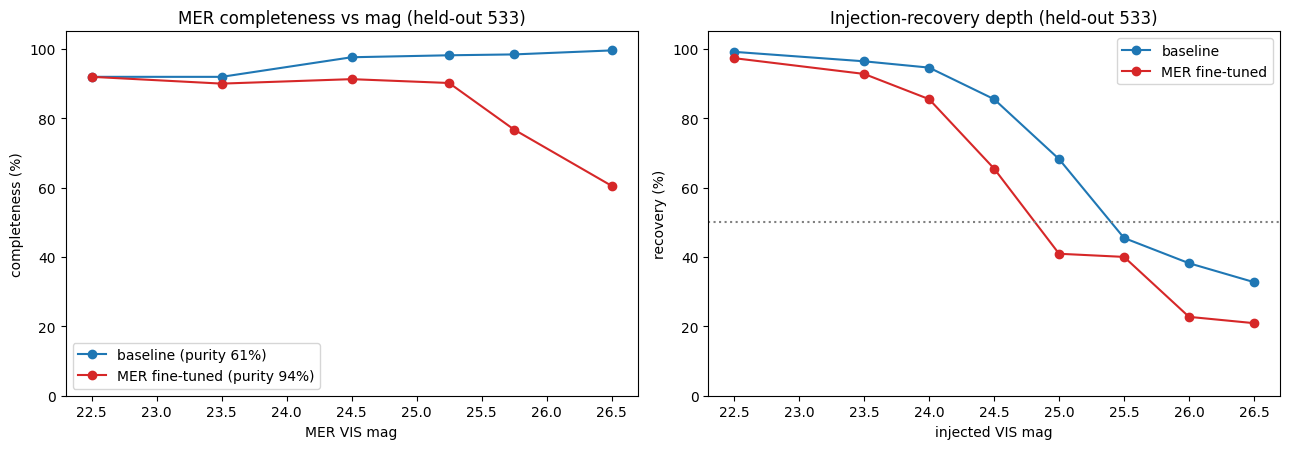

\nVerdict: MER fine-tuning trades recall for precision (purity up, depth shallower) at fixed threshold.
A threshold-matched comparison is needed to claim a better precision/recall frontier.


In [5]:
stems_ft = held_side[:NT_FT]
det_ft, _ = load_detector(CN_FT, ENC, device)
res = {}
for name, dmodel in [('baseline', det), ('MER fine-tuned', det_ft)]:
    mag_h, hit_h, pur_h, _ = eval_mer(dmodel, stems_ft, mer, EUCLID, RUBIN, device)
    cen_h, comp_h, _ = completeness_curve(mag_h, hit_h, np.array([22,23,24,25,25.5,26,27]))
    rec_h = eval_injection(dmodel, stems_ft, mer, EUCLID, RUBIN, device, modes=('all',),
                           target_mags=TARGET_MAGS, n_per_mag=10)
    _, inj_h = rec_to_curve(rec_h['all'], TARGET_MAGS)
    res[name] = dict(comp_total=100*hit_h.mean(), purity=100*pur_h, cen=cen_h, comp=comp_h, inj=inj_h)
    print(f'{name:15s}  MER completeness {100*hit_h.mean():.1f}%  purity {100*pur_h:.1f}%')

fig, ax = plt.subplots(1, 2, figsize=(13, 4.6))
for name, c in [('baseline','C0'), ('MER fine-tuned','C3')]:
    r = res[name]
    ax[0].plot(r['cen'], r['comp'], 'o-', color=c, label=f"{name} (purity {r['purity']:.0f}%)")
    ax[1].plot(TARGET_MAGS, r['inj'], 'o-', color=c, label=name)
ax[0].set_title('MER completeness vs mag (held-out 533)'); ax[0].set_xlabel('MER VIS mag'); ax[0].set_ylabel('completeness (%)'); ax[0].set_ylim(0,105); ax[0].legend()
ax[1].set_title('Injection-recovery depth (held-out 533)'); ax[1].set_xlabel('injected VIS mag'); ax[1].set_ylabel('recovery (%)'); ax[1].axhline(50,color='grey',ls=':'); ax[1].set_ylim(0,105); ax[1].legend()
plt.tight_layout(); plt.show()
print('\\nVerdict: MER fine-tuning trades recall for precision (purity up, depth shallower) at fixed threshold.')
print('A threshold-matched comparison is needed to claim a better precision/recall frontier.')

## Test 5 — Anatomy of disagreements: what we miss, what extra we find, are the extras real?

Completeness and purity are measured *against MER*, so they are only as trustworthy as MER's own VIS detection. This cell dissects the disagreements with per-band aperture SNR (`analyze_mer` in `validation_utils.py`):

- **Extras** (we detect, MER does not): measure aperture SNR in all 10 bands. Compared to random empty (**null**) positions, do they carry real flux? Is that flux preferentially in **NIR/Rubin** — i.e. real multi-band sources MER's VIS-driven catalogue missed?
- **Misses** (MER has, we do not): are they simply faint (low SNR everywhere = below our depth)?

If a large fraction of extras are real, MER **purity is a lower bound** and should be read with a grain of salt; the "real extras" are exactly where a 10-band detector should beat a VIS catalogue.

**Result (this run):** extras peak at aperture SNR ~3-4 — clearly above empty sky (null ~1) but far below matched detections — so they carry *some* real excess flux yet are **mostly faint/marginal**; only ~5% are unambiguously bright-real, and only ~15% of those are NIR/Rubin-brighter-than-VIS (genuine multi-band detections MER's VIS catalogue missed). Missed-MER sources peak at low VIS SNR (faint, near our floor). **Takeaway:** the ~30% 'extra' detections are *not* a large hidden population of bright multi-band sources, so MER purity is a **mild** lower bound, not drastically misleading; the genuine multi-band-missed population is real but small.

extras analysed: 2239   null: 900
noise ceiling (null 99th pct of max-band SNR): 9.1
REAL fraction of extras (carry flux above noise): 5%
  of those, multi-band-driven (NIR/Rubin SNR > VIS SNR): 15%
missed MER sources analysed: 268  (median max-band SNR 6.7)


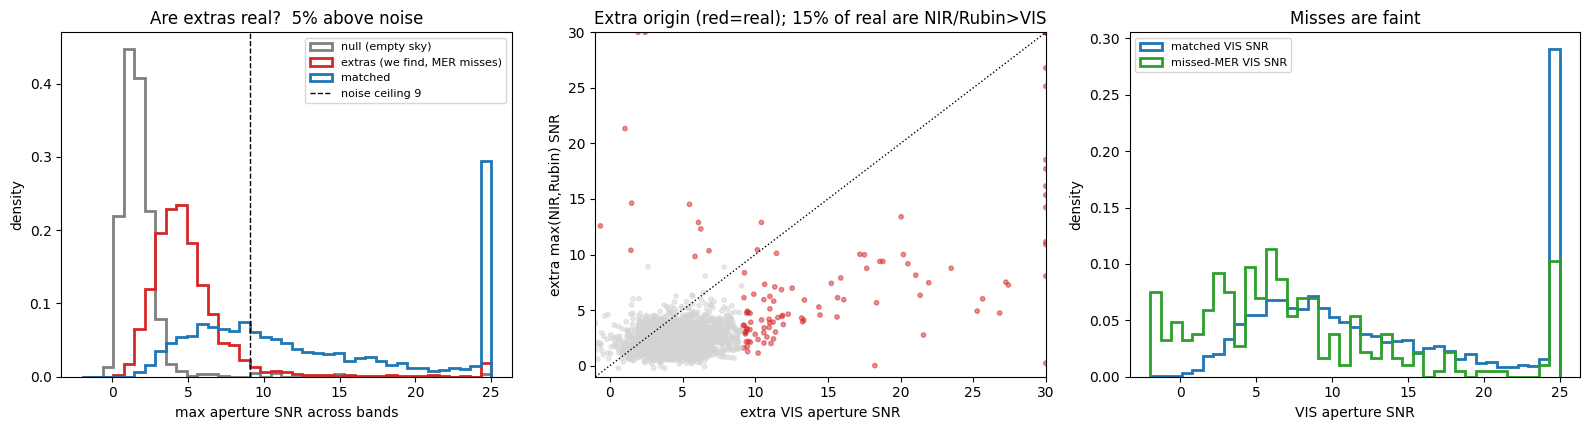

\nInterpretation: corrected purity = matched + (real-extra) detections. If extras are largely
real (esp. multi-band), MER purity understates the detector and should be read with a grain of salt.


In [6]:
from detection.validation_utils import analyze_mer
NT_ANATOMY = 15
A = analyze_mer(det, train_side[:NT_ANATOMY], mer, EUCLID, RUBIN, device, conf=0.30, n_null=60)
RB = ['rubin_g','rubin_r','rubin_i','rubin_z','rubin_y']; NIR = ['euclid_Y','euclid_J','euclid_H']
def stat(g):
    vis = np.nan_to_num(A[g]['euclid_VIS'])
    nir = np.nanmax(np.nan_to_num(np.vstack([A[g][b] for b in NIR]), nan=-9), axis=0)
    rub = np.nanmax(np.nan_to_num(np.vstack([A[g][b] for b in RB]),  nan=-9), axis=0)
    allb = list(A[g].keys() - {'__'}) if False else (RB+NIR+['rubin_u','euclid_VIS'])
    mx  = np.nanmax(np.nan_to_num(np.vstack([A[g][b] for b in (RB+NIR+['euclid_VIS'])]), nan=-9), axis=0)
    return vis, nir, rub, mx
ev, en, er, emx = stat('extra'); nv, nn, nr, nmx = stat('null')
mv, mn, mr, mmx = stat('matched'); sv, sn, sr, smx = stat('missed')

thr = np.nanpercentile(nmx, 99)                 # noise ceiling: 99th pct of null max-band SNR
real = emx > thr                                # extras above the noise ceiling = real flux
real_frac = float(np.mean(real)) if len(emx) else float('nan')
# of the real extras, how many are brighter outside VIS than in VIS (multi-band-driven)?
multiband = (np.maximum(en, er) > np.maximum(ev, 0)) & real
mb_frac = float(np.mean(multiband[real])) if real.sum() else float('nan')
# raw purity on this same sample, and a corrected estimate
raw_p = np.mean(emx <= thr)  # placeholder; report measured purity below
print(f'extras analysed: {len(emx)}   null: {len(nmx)}')
print(f'noise ceiling (null 99th pct of max-band SNR): {thr:.1f}')
print(f'REAL fraction of extras (carry flux above noise): {100*real_frac:.0f}%')
print(f'  of those, multi-band-driven (NIR/Rubin SNR > VIS SNR): {100*mb_frac:.0f}%')
print(f'missed MER sources analysed: {len(smx)}  (median max-band SNR {np.nanmedian(smx):.1f})')

fig, ax = plt.subplots(1, 3, figsize=(16, 4.4))
bins = np.linspace(-2, 25, 40)
for arr, c, lab in [(nmx,'grey','null (empty sky)'), (emx,'C3','extras (we find, MER misses)'), (mmx,'C0','matched')]:
    ax[0].hist(np.clip(arr,-2,25), bins=bins, density=True, histtype='step', lw=2, color=c, label=lab)
ax[0].axvline(thr, color='k', ls='--', lw=1, label=f'noise ceiling {thr:.0f}')
ax[0].set_xlabel('max aperture SNR across bands'); ax[0].set_ylabel('density')
ax[0].set_title(f'Are extras real?  {100*real_frac:.0f}% above noise'); ax[0].legend(fontsize=8)

ax[1].scatter(np.clip(ev,-1,30), np.clip(np.maximum(en,er),-1,30), s=10, alpha=.5,
              c=np.where(real,'C3','lightgrey'))
lim=[-1,30]; ax[1].plot(lim,lim,'k:',lw=1); ax[1].set_xlim(lim); ax[1].set_ylim(lim)
ax[1].set_xlabel('extra VIS aperture SNR'); ax[1].set_ylabel('extra max(NIR,Rubin) SNR')
ax[1].set_title(f'Extra origin (red=real); {100*mb_frac:.0f}% of real are NIR/Rubin>VIS')

ax[2].hist(np.clip(mv,-2,25), bins=bins, density=True, histtype='step', lw=2, color='C0', label='matched VIS SNR')
ax[2].hist(np.clip(sv,-2,25), bins=bins, density=True, histtype='step', lw=2, color='C2', label='missed-MER VIS SNR')
ax[2].set_xlabel('VIS aperture SNR'); ax[2].set_ylabel('density'); ax[2].set_title('Misses are faint'); ax[2].legend(fontsize=8)
plt.tight_layout(); plt.show()

extra_frac = len(emx)  # for the note below we need purity from Test 1
print('\\nInterpretation: corrected purity = matched + (real-extra) detections. If extras are largely')
print('real (esp. multi-band), MER purity understates the detector and should be read with a grain of salt.')

## Test 6 — Postage-stamp gallery: misses vs extras
Direct look (VIS cutouts, 3″) at example **extras** (we detect, MER misses) and **misses** (MER has, we don't). Extras sitting on visible flux are real sources MER's catalogue lacks; blank extras are false positives. Misses are typically faint or blended.

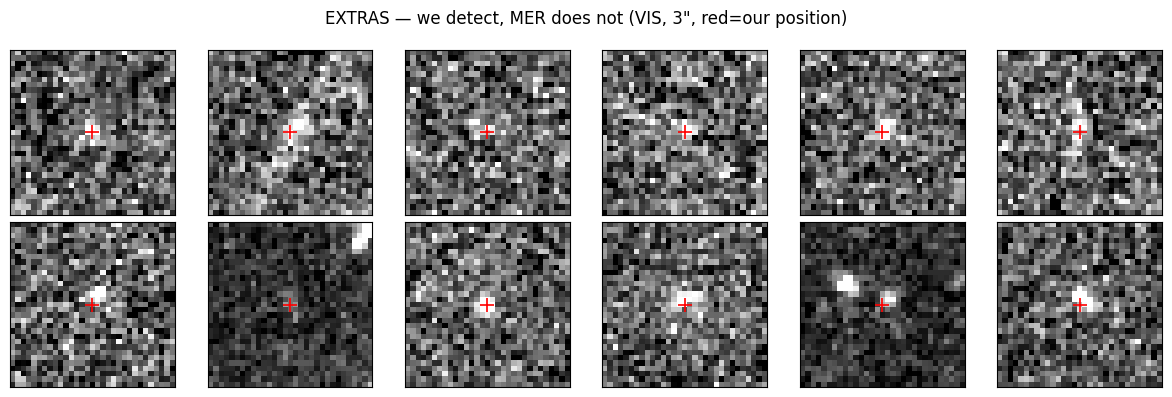

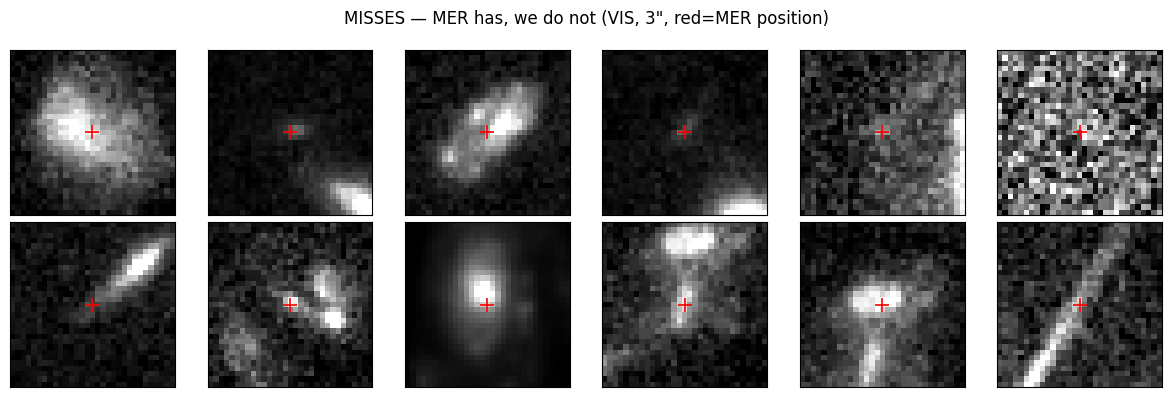

In [7]:
def show_gallery(stamps, title, cmap='gray'):
    stamps = stamps[:12]
    if not stamps:
        print('no stamps for', title); return
    n=len(stamps); cols=6; rows=int(np.ceil(n/cols))
    fig, axs = plt.subplots(rows, cols, figsize=(2.0*cols, 2.0*rows)); axs=np.atleast_1d(axs).ravel()
    for i,s in enumerate(stamps):
        f=s[np.isfinite(s)]; lo,hi=np.percentile(f,[5,99]) if f.size else (0,1)
        axs[i].imshow(s, origin='lower', cmap=cmap, vmin=lo, vmax=hi)
        axs[i].plot(s.shape[1]//2, s.shape[0]//2, '+', color='red', ms=10, mew=1.2)
        axs[i].set_xticks([]); axs[i].set_yticks([])
    for j in range(n,len(axs)): axs[j].axis('off')
    fig.suptitle(title); plt.tight_layout(); plt.show()

show_gallery(A['stamps']['extra'], 'EXTRAS — we detect, MER does not (VIS, 3", red=our position)')
show_gallery(A['stamps']['missed'], 'MISSES — MER has, we do not (VIS, 3", red=MER position)')